In [8]:
import time
import json
import subprocess
import sys
from pathlib import Path

def run_ref(script_path: Path, julia_bin="julia"):
    script_path = Path(script_path)
    suffix = script_path.suffix.lower()

    if suffix == ".py":
        cmd = [sys.executable, str(script_path)]
    elif suffix == ".jl":
        cmd = [julia_bin, str(script_path)]
    else:
        return {
            "status": "error",
            "engine": script_path.stem,
            "elapsed_s": 0.0,
            "stderr": f"unsupported script suffix: {suffix}",
            "stdout": "",
        }

    t0 = time.perf_counter()
    proc = subprocess.run(
        cmd, capture_output=True, text=True,
        encoding="utf-8", errors="replace",
    )
    elapsed_s = time.perf_counter() - t0

    if proc.returncode != 0:
        return {
            "status": "error",
            "engine": script_path.stem,
            "elapsed_s": elapsed_s,
            "stderr": proc.stderr,
            "stdout": proc.stdout,
        }

    out = json.loads(proc.stdout)
    if isinstance(out, dict):
        out["elapsed_s"] = elapsed_s
        out.setdefault("engine", script_path.stem)
    return out


ROOT = Path.cwd().resolve()
qutip_res = run_ref(ROOT / "task1_qutip_native_reference.py")
qoptics_res = run_ref(ROOT / "task1_quantumoptics_native_reference.jl")
qtoolbox_res = run_ref(ROOT / "task1_quantumtoolbox_native_reference.jl")

engines = ["python_qutip", "julia_qoptics", "julia_qtoolbox"]
cases   = ["baseline", "detuned"]

tri = {
    "python_qutip": qutip_res,
    "julia_qoptics": qoptics_res,
    "julia_qtoolbox": qtoolbox_res,
}
tri


{'python_qutip': {'engine': 'qutip_native',
  'cases': {'baseline': {'times': [0.0,
     1.0,
     2.0,
     3.0,
     4.0,
     5.0,
     6.0,
     7.0,
     8.0,
     9.0,
     10.0,
     11.0,
     12.0,
     13.0,
     14.0,
     15.0,
     16.0,
     17.0,
     18.0,
     19.0,
     20.0,
     21.0,
     22.0,
     23.0,
     24.0,
     25.0,
     26.0,
     27.0,
     28.0,
     29.0,
     30.0,
     31.0,
     32.0,
     33.0,
     34.0,
     35.0,
     36.0,
     37.0,
     38.0,
     39.0,
     40.0,
     41.0,
     42.0,
     43.0,
     44.0,
     45.0,
     46.0,
     47.0,
     48.0,
     49.0,
     50.0,
     51.0,
     52.0,
     53.0,
     54.0,
     55.0,
     56.0,
     57.0,
     58.0,
     59.0,
     60.0,
     61.0,
     62.0,
     63.0,
     64.0,
     65.0,
     66.0,
     67.0,
     68.0,
     69.0,
     70.0,
     71.0,
     72.0,
     73.0,
     74.0,
     75.0,
     76.0,
     77.0,
     78.0,
     79.0,
     80.0,
     81.0,
     82.0,
     83.0,
     84.0,
 

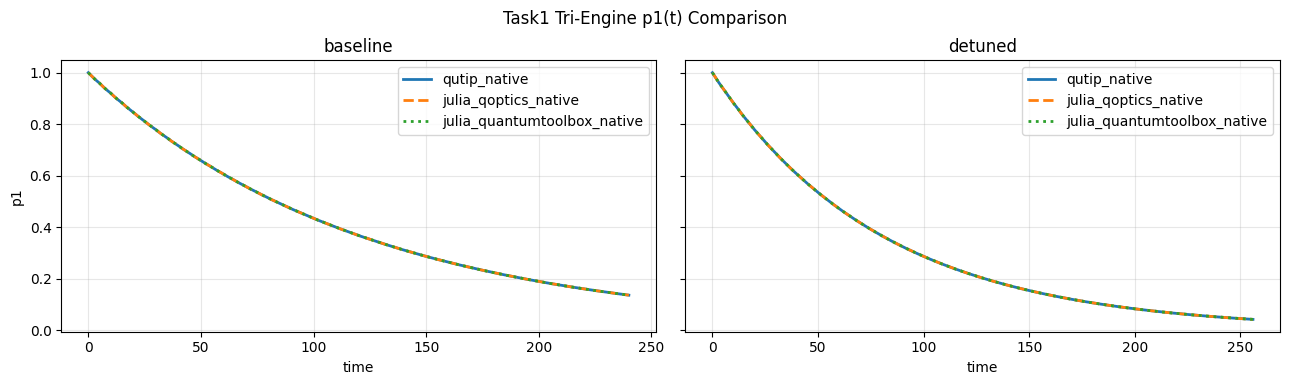

python_qutip 	 Elasped time: 3.8631297000101767
julia_qoptics 	 Elasped time: 13.603589800011832
julia_qtoolbox 	 Elasped time: 13.541034100053366


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

ls = ['-', '--', ':']
for ax, case in zip(axes, cases):
    for i, engine in enumerate(engines):
        res = tri[engine]["cases"][case]
        t = res["times"]
        p = res["p1_t"]
        ax.plot(t, p, label=tri[engine]["engine"], linewidth=2, linestyle=ls[i])

    ax.set_title(case)
    ax.set_xlabel("time")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("p1")
axes[0].legend(loc="best")    
fig.suptitle("Task1 Tri-Engine p1(t) Comparison", y=0.95)
plt.legend()
plt.tight_layout()
plt.show()

for engine in engines:
    print(f"{engine} \t Elasped time: {tri[engine]["elapsed_s"]}")

In [69]:
# Cell 1: imports + paths
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()  # 若 notebook 不在 repo 根目录，请改成你的 repo 根目录
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from qsim.analysis.trace_semantics import extract_p1_series
from qsim.ui.notebook import run_workflow

TASK1_JSON = ROOT / "required_tasks_tri_engine" / "task1_single_qubit_baseline.json"
BACKEND_PATH = ROOT.parent / "backend.yaml"
OUT_BASE = ROOT / "task1_outputs" / "workflow_task1_tri_engine"

task = json.loads(TASK1_JSON.read_text(encoding="utf-8"))
task["tag"], task["title"], task["engines"], task["solver_mode"]


('task1_single_qubit_baseline',
 'Task 1 单比特基准模型',
 ['qutip', 'julia_qtoolbox', 'julia_qoptics'],
 'me')

In [71]:
task["cases"]

[{'tag': 'baseline',
  'hardware': {'qubit_freqs_hz': [5.0], 'gate_duration': 20.0},
  'noise': {'model': 'markovian_lindblad', 't1': 120.0, 't2': 90.0},
  'note': 'baseline single-qubit model'},
 {'tag': 'detuned',
  'hardware': {'qubit_freqs_hz': [5.2], 'gate_duration': 28.0},
  'noise': {'model': 'markovian_lindblad', 't1': 80.0, 't2': 55.0},
  'note': 'detuned and slower gate'}]

In [72]:
# Cell 2: run task1 on three engines (baseline + detuned), collect dict
tri_result = {
    "task": task["tag"],
    "title": task["title"],
    "solver_mode": task.get("solver_mode", "me"),
    "engines": list(task["engines"]),
    "cases": {},
}

for case in task["cases"]:
    case_tag = case["tag"]
    hardware = dict(case.get("hardware", {}) or {})
    noise = dict(case.get("noise", {}) or {})
    tri_result["cases"][case_tag] = {}

    for engine in task["engines"]:
        out_dir = OUT_BASE / case_tag / engine
        t0 = time.perf_counter()

        result = run_workflow(
            qasm_text=task["qasm_text"],
            backend_path=str(BACKEND_PATH),
            out_dir=str(out_dir),
            hardware=hardware,
            noise=noise,
            engine=engine,
            solver_mode=task.get("solver_mode", "me"),
            persist_artifacts=False,  # 不落盘工件；仅拿运行结果
            export_dxf=False,
            export_plots=False,
            decoder="mock",
            allow_mock_fallback=False,
        )

        elapsed_s = time.perf_counter() - t0
        trace = result["trace"]
        p1_t = [float(x) for x in extract_p1_series(trace)]
        times = [float(x) for x in trace.times[:len(p1_t)]]

        tri_result["cases"][case_tag][engine] = {
            "elapsed_s": elapsed_s,
            "times": times,
            "p1_t": p1_t,
            "final_p1": p1_t[-1] if p1_t else None,
            "trace_engine": trace.engine,
            "state_encoding": str(getattr(trace, "metadata", {}).get("state_encoding", "unknown")),
            "solver_mode_used": result.get("solver_mode"),
        }

tri_result


{'task': 'task1_single_qubit_baseline',
 'title': 'Task 1 单比特基准模型',
 'solver_mode': 'me',
 'engines': ['qutip', 'julia_qtoolbox', 'julia_qoptics'],
 'cases': {'baseline': {'qutip': {'elapsed_s': 1.9151476999977604,
    'times': [0.0,
     1.0,
     2.0,
     3.0,
     4.0,
     5.0,
     6.0,
     7.0,
     8.0,
     9.0,
     10.0,
     11.0,
     12.0,
     13.0,
     14.0,
     15.0,
     16.0,
     17.0,
     18.0,
     19.0,
     20.0,
     21.0,
     22.0,
     23.0,
     24.0,
     25.0,
     26.0,
     27.0,
     28.0,
     29.0,
     30.0,
     31.0,
     32.0,
     33.0,
     34.0,
     35.0,
     36.0,
     37.0,
     38.0,
     39.0,
     40.0,
     41.0,
     42.0,
     43.0,
     44.0,
     45.0,
     46.0,
     47.0,
     48.0,
     49.0,
     50.0,
     51.0,
     52.0,
     53.0,
     54.0,
     55.0,
     56.0,
     57.0,
     58.0,
     59.0,
     60.0,
     61.0,
     62.0,
     63.0,
     64.0,
     65.0,
     66.0,
     67.0,
     68.0,
     69.0,
     70.0,
     

In [87]:
# Cell 3: quick table (final_p1 / mean_p1 / elapsed_s)
rows = []
for case_tag, engines in tri_result["cases"].items():
    for engine, payload in engines.items():
        rows.append({
            "case": case_tag,
            "engine": engine,
            "final_p1": payload["final_p1"],
            "elapsed_s": payload["elapsed_s"],
            "encoding": payload["state_encoding"],
        })

import pandas as pd
pd.DataFrame(rows).sort_values(["case", "engine"]).reset_index(drop=True)


,case,engine,final_p1,elapsed_s,encoding
0,baseline,julia_qoptics,0.657894,18.436175,basis_population_single_qubit
1,baseline,julia_qtoolbox,0.657891,33.226370,basis_population_single_qubit
2,baseline,qutip,0.999760,1.915148,per_qubit_excited_probability
3,detuned,julia_qoptics,0.646677,18.508327,basis_population_single_qubit
4,detuned,julia_qtoolbox,0.646669,18.852934,basis_population_single_qubit
5,detuned,qutip,0.999996,0.043997,per_qubit_excited_probability
